# Time-Series Forecasting of Carbon Monoxide and Nitrogen Dioxide Levels

Build predictive models to forecast daily or hourly concentrations of **CO(GT)** and **NO₂(GT)** based on historical data.


In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [170]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/airquality.csv'
df = pd.read_csv(url)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [171]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


# Project Workflow

### **Deliverables**:
1. **Forecasting Models**:
   - Trained models for `CO(GT)` and `NO₂(GT)`.
2. **Forecast Visualization**:
   - Plots showing historical trends and future predictions.
3. **Evaluation Report**:
   - Metrics and comparison of different forecasting models.
4. **Insights and Recommendations**:
   - Suggestions for mitigating high levels of these gases based on predictions.


### 1. Data Preprocessing
- **Date-Time Parsing**:
  - Combine the `Date` and `Time` columns into a single `datetime` column.
  - Set the `datetime` column as the index of the dataset.
- **Resampling**:
  - Aggregate the data into meaningful time intervals (e.g., hourly or daily averages).
- **Handle Missing Values**:
  - Use interpolation, mean, or advanced imputation techniques to fill missing data for `CO(GT)` and `NO₂(GT)`.
- **Outlier Detection**:
  - Remove or cap extreme values in `CO(GT)` and `NO₂(GT)` using statistical thresholds.

In [173]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [174]:
df['is_4am'] = (df.index.hour == 4).astype(int)
df['is_3am'] = (df.index.hour ==3).astype(int)

In [175]:
df_hourly = df.resample('H').mean()
df_hourly.head()

/tmp/ipykernel_13709/3066627971.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,is_4am,is_3am
datetime,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,0.0,0.0
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,0.0,0.0
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,0.0,0.0
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,0.0,0.0
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,0.0,0.0


In [176]:
window = 24*15
upper_quantile = 0.995

df_processed = df_hourly.copy()

for col in ['CO(GT)', 'NO2(GT)']:
    rolling_upper = df_processed[col].rolling(window, min_periods=1).quantile(upper_quantile)
    df_processed[col] = np.where(df_processed[col] > rolling_upper, rolling_upper, df_processed[col])


In [177]:

df_processed['is_4am'][5:14]

datetime
2004-03-10 23:00:00    0.0
2004-03-11 00:00:00    0.0
2004-03-11 01:00:00    0.0
2004-03-11 02:00:00    0.0
2004-03-11 03:00:00    0.0
2004-03-11 04:00:00    1.0
2004-03-11 05:00:00    0.0
2004-03-11 06:00:00    0.0
2004-03-11 07:00:00    0.0
Freq: h, Name: is_4am, dtype: float64

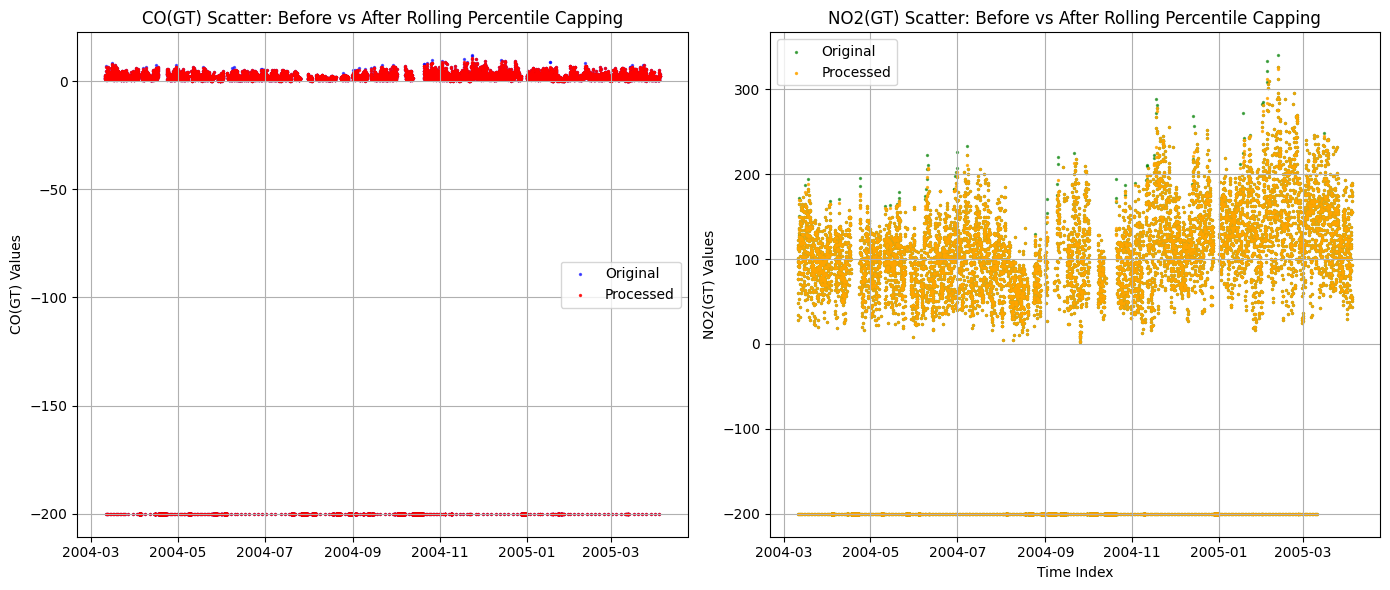

In [178]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CO(GT)
axes[0].scatter(df_hourly.index, df_hourly['CO(GT)'], label='Original', color='blue', alpha=0.6, s=2)
axes[0].scatter(df_processed.index, df_processed['CO(GT)'], label='Processed', color='red', alpha=0.8, s=2)
axes[0].set_title("CO(GT) Scatter: Before vs After Rolling Percentile Capping")
axes[0].set_ylabel("CO(GT) Values")
axes[0].legend()
axes[0].grid(True)

# NO2(GT)
axes[1].scatter(df_hourly.index, df_hourly['NO2(GT)'], label='Original', color='green', alpha=0.6, s=2)
axes[1].scatter(df_processed.index, df_processed['NO2(GT)'], label='Processed', color='orange', alpha=0.8, s=2)
axes[1].set_title("NO2(GT) Scatter: Before vs After Rolling Percentile Capping")
axes[1].set_ylabel("NO2(GT) Values")
axes[1].legend()
axes[1].grid(True)

plt.xlabel("Time Index")
plt.tight_layout()
plt.show()


In [179]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Freq: h
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float64
 1   PT08.S1(CO)    9357 non-null   float64
 2   NMHC(GT)       9357 non-null   float64
 3   C6H6(GT)       9357 non-null   float64
 4   PT08.S2(NMHC)  9357 non-null   float64
 5   NOx(GT)        9357 non-null   float64
 6   PT08.S3(NOx)   9357 non-null   float64
 7   NO2(GT)        9357 non-null   float64
 8   PT08.S4(NO2)   9357 non-null   float64
 9   PT08.S5(O3)    9357 non-null   float64
 10  T              9357 non-null   float64
 11  RH             9357 non-null   float64
 12  AH             9357 non-null   float64
 13  is_4am         9357 non-null   float64
 14  is_3am         9357 non-null   float64
dtypes: float64(15)
memory usage: 1.1 MB


### 2. Exploratory Data Analysis (EDA)
- **Trend Analysis**:
  - Visualize the long-term trends of `CO(GT)` and `NO₂(GT)`.
- **Seasonality**:
  - Identify seasonal patterns (e.g., daily or yearly fluctuations).
- **Correlation Analysis**:
  - Explore relationships between `CO(GT)`, `NO₂(GT)`, and other features (e.g., temperature or humidity).


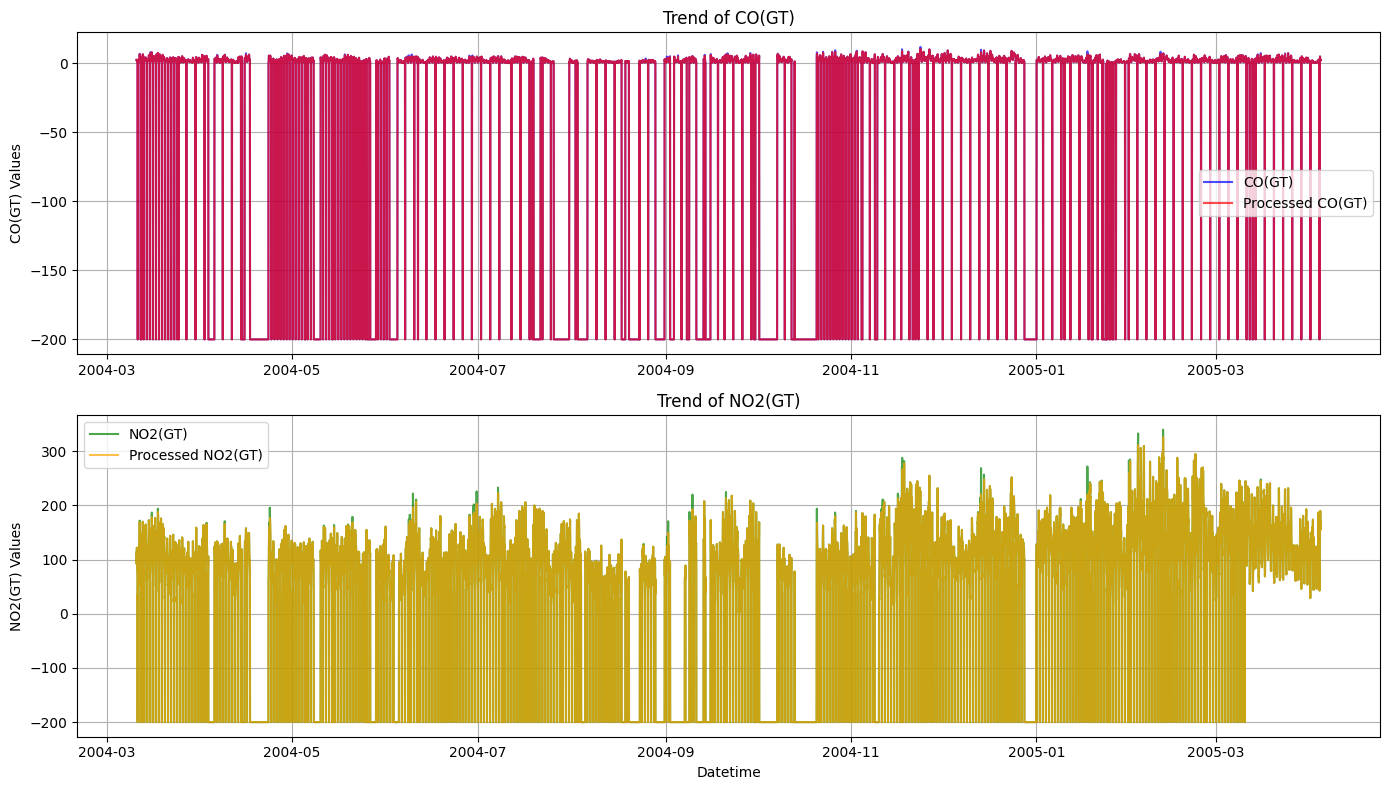

In [180]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# CO(GT) Trend
axes[0].plot(df_hourly.index, df_hourly['CO(GT)'], label='CO(GT)', color='blue', alpha=0.7)
axes[0].plot(df_processed.index, df_processed['CO(GT)'], label='Processed CO(GT)', color='red', alpha=0.7)
axes[0].set_title("Trend of CO(GT)")
axes[0].set_ylabel("CO(GT) Values")
axes[0].legend()
axes[0].grid(True)

# NO2(GT) Trend
axes[1].plot(df_hourly.index, df_hourly['NO2(GT)'], label='NO2(GT)', color='green', alpha=0.7)
axes[1].plot(df_processed.index, df_processed['NO2(GT)'], label='Processed NO2(GT)', color='orange', alpha=0.7)
axes[1].set_title("Trend of NO2(GT)")
axes[1].set_ylabel("NO2(GT) Values")
axes[1].legend()
axes[1].grid(True)

plt.xlabel("Datetime")
plt.tight_layout()
plt.show()


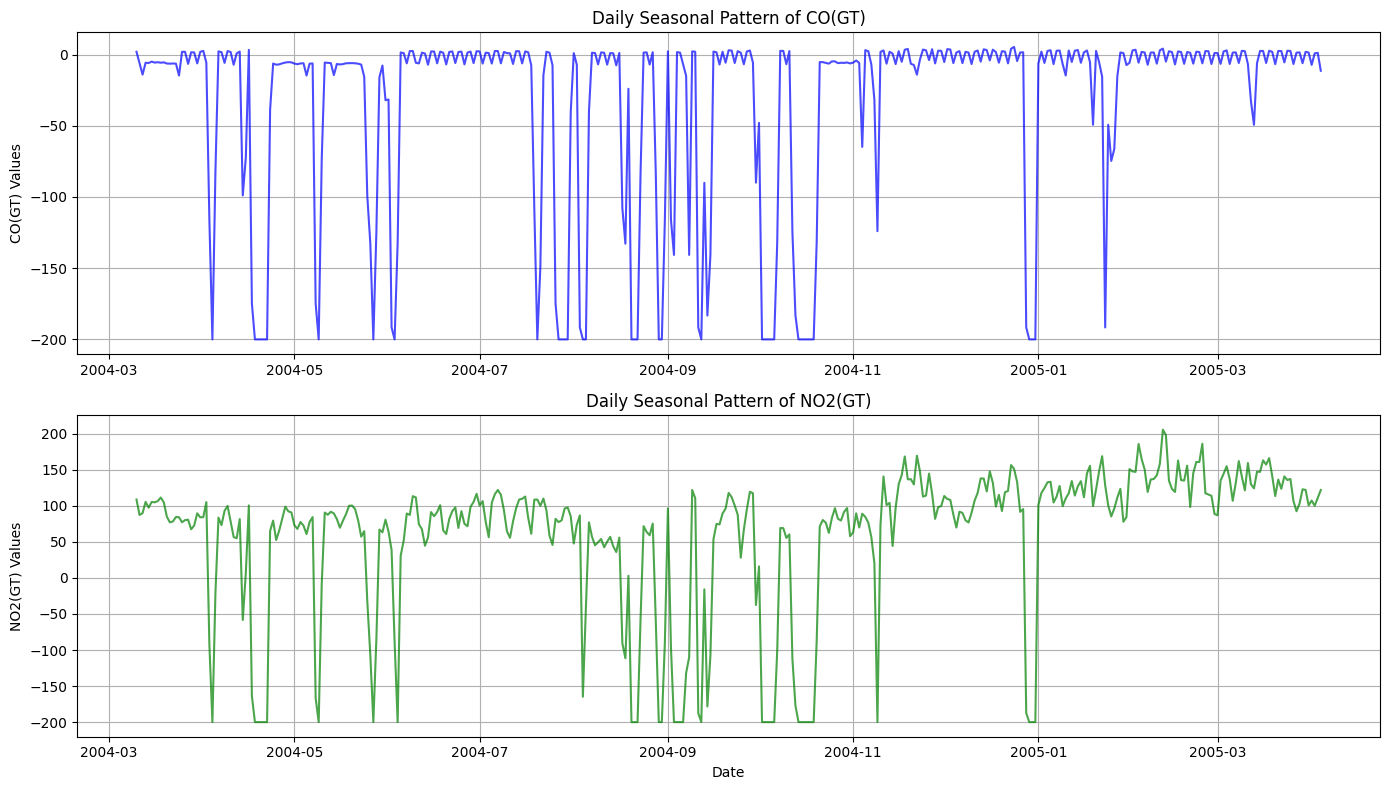

In [181]:
daily_data = df_hourly[['CO(GT)', 'NO2(GT)']].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_data.index, daily_data['CO(GT)'], color='blue', alpha=0.7)
axes[0].set_title("Daily Seasonal Pattern of CO(GT)")
axes[0].set_ylabel("CO(GT) Values")
axes[0].grid(True)

axes[1].plot(daily_data.index, daily_data['NO2(GT)'], color='green', alpha=0.7)
axes[1].set_title("Daily Seasonal Pattern of NO2(GT)")
axes[1].set_ylabel("NO2(GT) Values")
axes[1].grid(True)

plt.xlabel("Date")
plt.tight_layout()
plt.show()


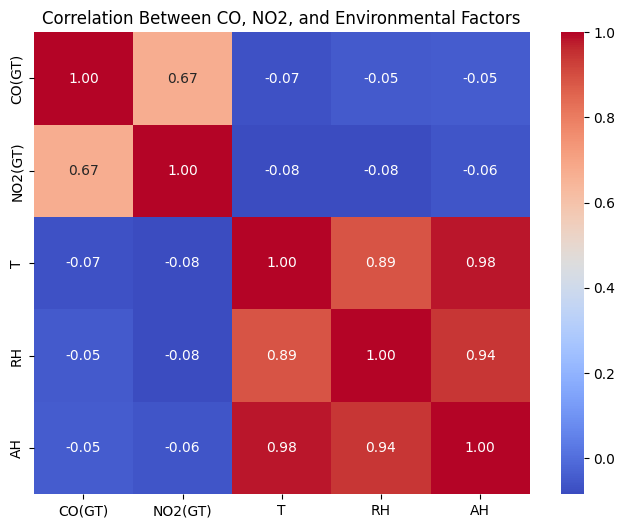

In [182]:

corr_cols = ['CO(GT)', 'NO2(GT)', 'T', 'RH', 'AH']  # Temperature, Humidity, Absolute Humidity
corr_matrix = df_processed[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between CO, NO2, and Environmental Factors")
plt.show()



### 3. Feature Engineering
- Create lag features for `CO(GT)` and `NO₂(GT)` to incorporate historical values.
- Add time-based features (e.g., hour of the day, day of the week, month).
- Include environmental factors (`T`, `RH`, `AH`) as predictors.


In [183]:
lags = [1, 2, 3]  # lag by 1, 2, 3 hours
for col in ['CO(GT)', 'NO2(GT)']:
    for lag in lags:
        df_processed[f'{col}_lag{lag}'] = df_processed[col].shift(lag)
df_processed

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),...,RH,AH,is_4am,is_3am,CO(GT)_lag1,CO(GT)_lag2,CO(GT)_lag3,NO2(GT)_lag1,NO2(GT)_lag2,NO2(GT)_lag3
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.00,1692.0,1268.0,...,48.9,0.7578,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.00,1559.0,972.0,...,47.7,0.7255,0.0,0.0,2.6,NaN,NaN,113.00,NaN,NaN
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,113.99,1555.0,1074.0,...,54.0,0.7502,0.0,0.0,2.0,2.6,NaN,92.00,113.00,NaN
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,121.88,1584.0,1203.0,...,60.0,0.7867,0.0,0.0,2.2,2.0,2.6,113.99,92.00,113.0
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.00,1490.0,1110.0,...,59.6,0.7888,0.0,0.0,2.2,2.2,2.0,121.88,113.99,92.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.00,1374.0,1729.0,...,29.3,0.7568,0.0,0.0,3.9,5.0,4.0,187.00,174.00,155.0
2005-04-04 11:00:00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.00,1264.0,1269.0,...,23.7,0.7119,0.0,0.0,3.1,3.9,5.0,190.00,187.00,174.0
2005-04-04 12:00:00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.00,1241.0,1092.0,...,18.3,0.6406,0.0,0.0,2.4,3.1,3.9,179.00,190.00,187.0


In [184]:
df_processed['hour'] = df_processed.index.hour
df_processed['day_of_week'] = df_processed.index.dayofweek  
df_processed['month'] = df_processed.index.month


### 4. Time-Series Forecasting
- Train separate models for **CO(GT)** and **NO₂(GT)**.
- Explore the following forecasting approaches:
  - **Statistical Models**:
    - Classical models like ARIMA or SARIMA for univariate forecasting.
  - **Machine Learning Models**:
    - Use regression models trained on lag features and external predictors.
  - **Deep Learning Models**:
    - Apply LSTM, GRU, or other RNN-based models for sequence forecasting.
- Evaluate and compare the models.


In [185]:
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
df_processed.dropna(inplace=True)

In [186]:
features_CO = [
    'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
    'PT08.S5(O3)', 'T', 'RH', 'AH',
    'CO(GT)_lag1', 'CO(GT)_lag2', 'CO(GT)_lag3',
    'NO2(GT)_lag1', 'NO2(GT)_lag2', 'NO2(GT)_lag3',
    'hour', 'day_of_week', 'month','is_4am'
]
target_CO = 'CO(GT)'

features_NO2 = [
    'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'CO(GT)', 'PT08.S4(NO2)',
    'PT08.S5(O3)', 'T', 'RH', 'AH',
    'NO2(GT)_lag1', 'NO2(GT)_lag2', 'NO2(GT)_lag3',
    'CO(GT)_lag1', 'CO(GT)_lag2', 'CO(GT)_lag3',
    'hour', 'day_of_week', 'month','is_3am'
]
target_NO2 = 'NO2(GT)'

In [187]:
split = int(0.8 * len(df_processed))

train_CO = df_processed.iloc[:split]
test_CO = df_processed.iloc[split:]

train_NO2 = df_processed.iloc[:split]
test_NO2 = df_processed.iloc[split:]


In [188]:
X_train_CO = train_CO[features_CO]
y_train_CO = train_CO[target_CO]
X_test_CO = test_CO[features_CO]
y_test_CO = test_CO[target_CO]

In [189]:
X_train_NO2 = train_NO2[features_NO2]
y_train_NO2 = train_NO2[target_NO2]
X_test_NO2 = test_NO2[features_NO2]
y_test_NO2 = test_NO2[target_NO2]

In [190]:
def train_arima_model(y_train, target_name, order=(5,1,0)):
    print(f"\nTraining ARIMA model for {target_name} with order={order}...")
    model = ARIMA(y_train, order=order)
    arima_model = model.fit()
    print(arima_model.summary())
    return arima_model

arima_model_co = train_arima_model(train_CO[target_CO], "CO(GT)", order=(5,1,0))

arima_model_no2 = train_arima_model(train_NO2[target_NO2], "NO2(GT)", order=(5,1,0))


Training ARIMA model for CO(GT) with order=(5, 1, 0)...
                               SARIMAX Results                                
Dep. Variable:                 CO(GT)   No. Observations:                 7483
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -37445.387
Date:                Mon, 06 Oct 2025   AIC                          74902.773
Time:                        12:20:18   BIC                          74944.295
Sample:                    03-10-2004   HQIC                         74917.033
                         - 01-16-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5127      0.005   -109.712      0.000      -0.522      -0.504
ar.L2         -0.2856      0.008    -33.799      0.000      -0.302      -0

In [191]:
def train_sarima_model(y_train, target_name, order=(1,1,1), seasonal_order=(1,1,1,24)):
    
    print(f"\nTraining SARIMA model for {target_name} with order={order} and seasonal_order={seasonal_order}...")
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    sarima_model = model.fit(disp=False)
    print(sarima_model.summary())
    return sarima_model

sarima_model_co = train_sarima_model(train_CO[target_CO], "CO(GT)", order=(1,1,1), seasonal_order=(1,1,1,24))
sarima_model_no2 = train_sarima_model(train_NO2[target_NO2], "NO2(GT)", order=(1,1,1), seasonal_order=(1,1,1,24))


Training SARIMA model for CO(GT) with order=(1, 1, 1) and seasonal_order=(1, 1, 1, 24)...
                                     SARIMAX Results                                      
Dep. Variable:                             CO(GT)   No. Observations:                 7483
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -36092.432
Date:                            Mon, 06 Oct 2025   AIC                          72194.863
Time:                                    12:20:49   BIC                          72229.431
Sample:                                03-10-2004   HQIC                         72206.739
                                     - 01-16-2005                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0698  

In [192]:
rf_co = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_co.fit(X_train_CO, y_train_CO)

rf_no2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_no2.fit(X_train_NO2, y_train_NO2)

RandomForestRegressor(max_depth=15, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [193]:
xgb_co = XGBRegressor(
    n_estimators=300,
    max_depth=15,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)
xgb_co.fit(X_train_CO, y_train_CO)


xgb_no2 = XGBRegressor(
    n_estimators=300,
    max_depth=15,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)
xgb_no2.fit(X_train_NO2, y_train_NO2)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=15, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [194]:
def train_lstm_model(X_train, y_train, target_name):
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))

    X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[1])),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    print(f"\nLSTM Model Summary for {target_name}:")
    model.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    print(f"\nTraining LSTM model for {target_name}...")
    history = model.fit(
        X_train_scaled, y_train_scaled, validation_split=0.2,
        epochs=100, batch_size=32, verbose=1, callbacks=[early_stop]
    )

    return model, scaler_X, scaler_y



In [195]:
lstm_model_co, scaler_X_co, scaler_y_co = train_lstm_model(train_CO[features_CO], train_CO[target_CO], "CO(GT)")



LSTM Model Summary for CO(GT):


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 64)          │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,233 (137.63 KB)

 Trainable params: 35,233 (137.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model for CO(GT)...
Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.2485 - val_loss: 0.0179
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0301 - val_loss: 0.0166
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0235 - val_loss: 0.0150
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0209 - val_loss: 0.0154
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0190 - val_loss: 0.0136
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0179 - val_loss: 0.0147
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0137 - val_loss: 0.0172
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0168 - val_loss: 0.0173
Epoch 9/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0173 - val_loss: 0.0138
Epoch 10/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0165 - val_loss: 0.0206
Epoch 11/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0173 - val_loss: 0.0133
Epoch 

In [196]:
lstm_model_no2, scaler_X_no2, scaler_y_no2 = train_lstm_model(train_NO2[features_NO2], train_NO2[target_NO2], "NO2(GT)")


LSTM Model Summary for NO2(GT):


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 1, 64)          │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,233 (137.63 KB)

 Trainable params: 35,233 (137.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model for NO2(GT)...
Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0970 - val_loss: 0.0078
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0098 - val_loss: 0.0058
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0061 - val_loss: 0.0033
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0044 - val_loss: 0.0031
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0038 - val_loss: 0.0027
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0033 - val_loss: 0.0026
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021 - val_loss: 0.0031
Epoch 9/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 0.0040
Epoch 10/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 11/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch

In [197]:
def train_gru_model(X_train, y_train, target_name):
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))

    X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))

    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(1, X_train.shape[1])),
        Dropout(0.2),
        GRU(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    print(f"\nGRU Model Summary for {target_name}:")
    model.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    print(f"\nTraining GRU model for {target_name}...")
    history = model.fit(
        X_train_scaled, y_train_scaled, validation_split=0.2,
        epochs=100, batch_size=32, verbose=1, callbacks=[early_stop]
    )

    return model, scaler_X, scaler_y



In [198]:
gru_model_co, scaler_X_co, scaler_y_co = train_gru_model(train_CO[features_CO], train_CO[target_CO], "CO(GT)")


GRU Model Summary for CO(GT):


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_12 (GRU)                    │ (None, 1, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_13 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,849 (104.88 KB)

 Trainable params: 26,849 (104.88 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU model for CO(GT)...
Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1212 - val_loss: 0.0159
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0258 - val_loss: 0.0167
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0231 - val_loss: 0.0156
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0196 - val_loss: 0.0144
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0225 - val_loss: 0.0149
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0187 - val_loss: 0.0141
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0170 - val_loss: 0.0163
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0174 - val_loss: 0.0138
Epoch 9/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0167 - val_loss: 0.0151
Epoch 10/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0166 - val_loss: 0.0145
Epoch 11/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0176 - val_loss: 0.0129
Epoch 1

In [199]:
gru_model_no2, scaler_X_no2, scaler_y_no2 = train_gru_model(train_NO2[features_NO2], train_NO2[target_NO2], "NO2(GT)")


GRU Model Summary for NO2(GT):


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_14 (GRU)                    │ (None, 1, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,849 (104.88 KB)

 Trainable params: 26,849 (104.88 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU model for NO2(GT)...
Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0588 - val_loss: 0.0068
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0083 - val_loss: 0.0042
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - val_loss: 0.0036
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0046 - val_loss: 0.0036
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0023 - val_loss: 0.0038
Epoch 9/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 10/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 11/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015 - val_loss: 0.0042
Epoch 

### 5. Model Evaluation
- Use appropriate metrics for forecasting:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - Mean Absolute Percentage Error (MAPE)
- Plot actual vs. predicted values to visualize performance.


In [200]:
def evaluate_arima_model(model, y_train, y_test, target_name):
    y_pred = model.forecast(steps=len(y_test))

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / (y_test.values + 1e-8))) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 {target_name} ARIMA Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")

    plt.figure(figsize=(20,5))
    plt.plot(y_train.index.append(y_test.index), 
             np.concatenate([y_train.values, y_pred]), 
             label='Predicted', color='red')
    plt.plot(y_train.index.append(y_test.index), 
             np.concatenate([y_train.values, y_test.values]), 
             label='Actual',alpha=0.5)
    plt.title(f"{target_name} - ARIMA Predictions")
    plt.legend()
    plt.show()

    return y_pred



📊 CO(GT) ARIMA Evaluation:
RMSE: 44.3167
MAE:  10.9669
MAPE: 63.52%
R²:   -0.0396


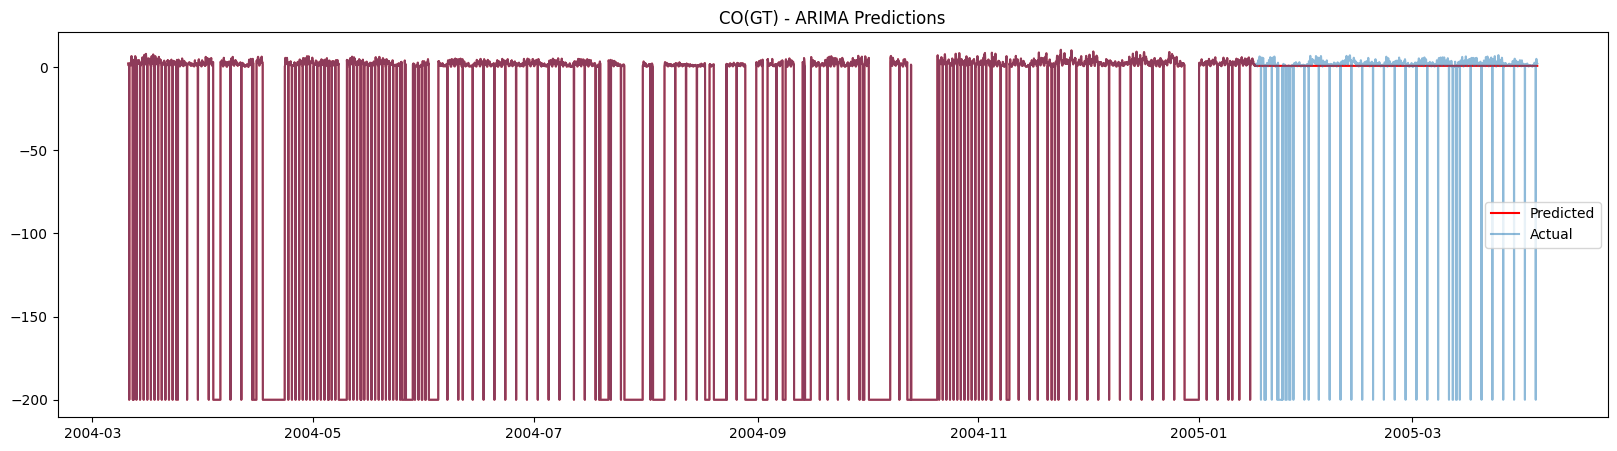

In [201]:
y_pred_CO_arima = evaluate_arima_model(arima_model_co, train_CO[target_CO], test_CO[target_CO], "CO(GT)")


📊 NO2(GT) ARIMA Evaluation:
RMSE: 92.8874
MAE:  71.5309
MAPE: 45.42%
R²:   -0.3673


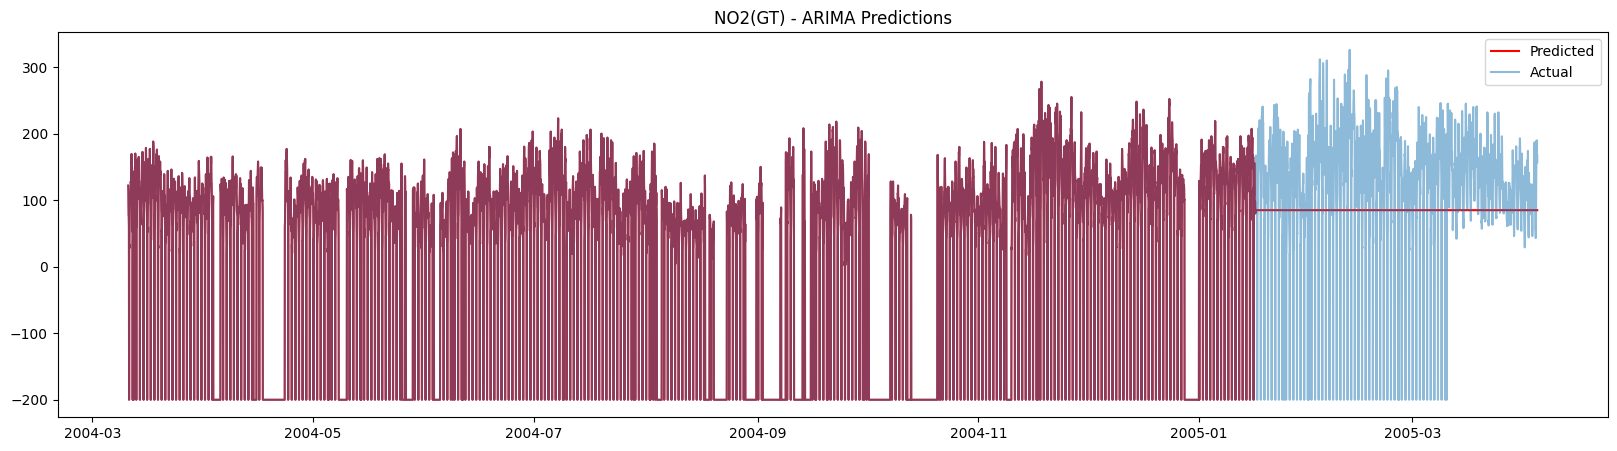

In [202]:

y_pred_NO2_arima = evaluate_arima_model(arima_model_no2, train_NO2[target_NO2], test_NO2[target_NO2], "NO2(GT)")

In [203]:
def evaluate_sarima_model(model, y_train, y_test, target_name):
    y_pred = model.forecast(steps=len(y_test))
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / (y_test.values + 1e-8))) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 {target_name} SARIMA Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_train.index.append(y_test.index), 
             np.concatenate([y_train.values, y_pred]), 
             label='Predicted', color='red')
    plt.plot(y_train.index.append(y_test.index), 
             np.concatenate([y_train.values, y_test.values]), 
             label='Actual')
    plt.title(f"{target_name} - SARIMA Predictions")
    plt.legend()
    plt.show()

    return y_pred


📊 CO(GT) SARIMA Evaluation:
RMSE: 69.7365
MAE:  54.4108
MAPE: 3826.06%
R²:   -1.5744


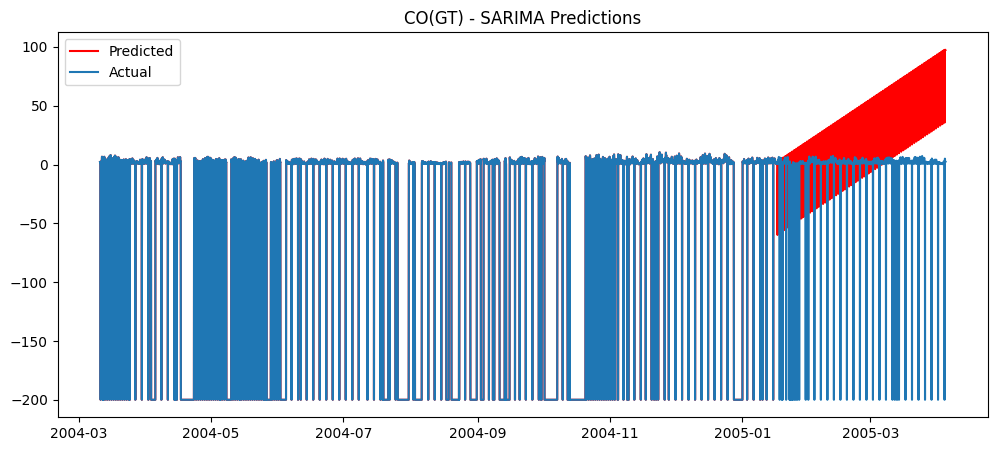

In [204]:
y_pred_CO_sarima = evaluate_sarima_model(sarima_model_co, train_CO[target_CO], test_CO[target_CO], "CO(GT)")



📊 NO2(GT) SARIMA Evaluation:
RMSE: 215.6022
MAE:  201.0840
MAPE: 157.21%
R²:   -6.3662


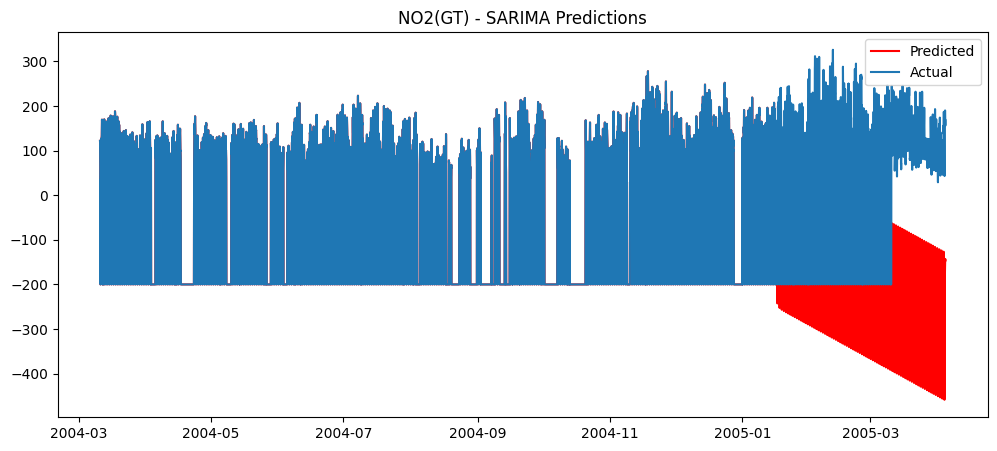

In [205]:
y_pred_NO2_sarima = evaluate_sarima_model(sarima_model_no2, train_NO2[target_NO2], test_NO2[target_NO2], "NO2(GT)")

CO(GT) → RMSE: 32.228, MAE: 10.869, MAPE: 1236.37%, R²: 0.450


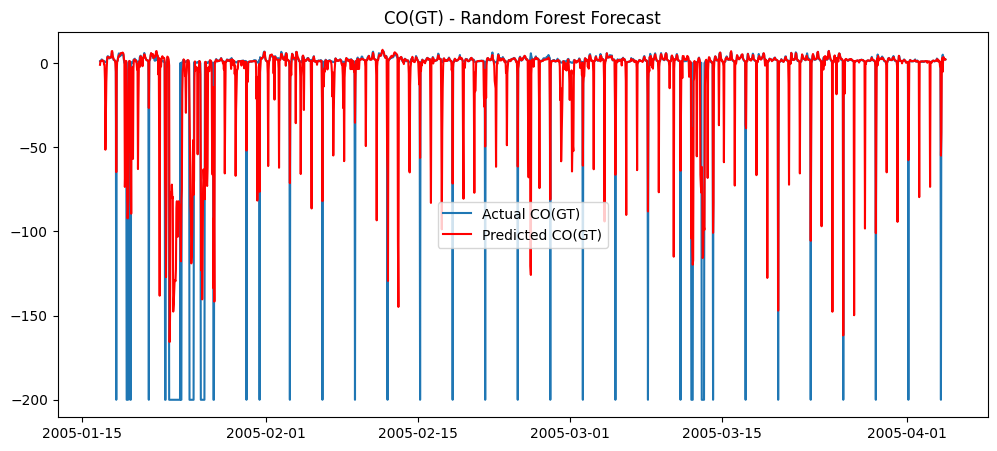

In [206]:
rand_pred_CO = rf_co.predict(X_test_CO)

rmse_co = np.sqrt(mean_squared_error(y_test_CO, rand_pred_CO))
mae_co = mean_absolute_error(y_test_CO, rand_pred_CO)
mape_co = np.mean(np.abs((y_test_CO - rand_pred_CO) / y_test_CO)) * 100
r2_co = r2_score(y_test_CO, rand_pred_CO)

print(f"CO(GT) → RMSE: {rmse_co:.3f}, MAE: {mae_co:.3f}, MAPE: {mape_co:.2f}%, R²: {r2_co:.3f}")

plt.figure(figsize=(12,5))
plt.plot(y_test_CO.index, y_test_CO, label='Actual CO(GT)')
plt.plot(y_test_CO.index, rand_pred_CO, label='Predicted CO(GT)', color='red')
plt.legend()
plt.title("CO(GT) - Random Forest Forecast")
plt.show()


NO₂(GT) → RMSE: 23.695, MAE: 16.881, MAPE: 11.51%, R²: 0.911


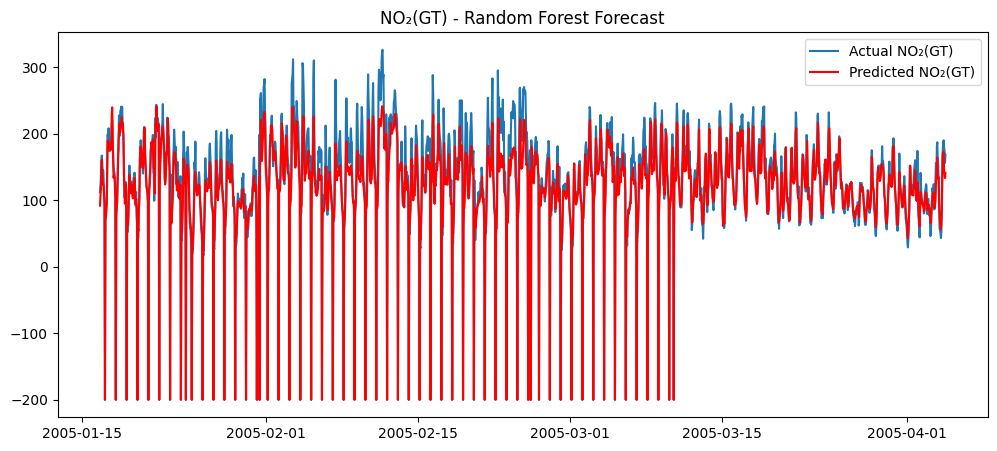

In [207]:
pred_NO2 = rf_no2.predict(X_test_NO2)

rmse_no2 = np.sqrt(mean_squared_error(y_test_NO2, pred_NO2))
mae_no2 = mean_absolute_error(y_test_NO2, pred_NO2)
mape_no2 = np.mean(np.abs((y_test_NO2 - pred_NO2) / y_test_NO2)) * 100
r2_no2 = r2_score(y_test_NO2, pred_NO2)

print(f"NO₂(GT) → RMSE: {rmse_no2:.3f}, MAE: {mae_no2:.3f}, MAPE: {mape_no2:.2f}%, R²: {r2_no2:.3f}")

plt.figure(figsize=(12,5))
plt.plot(y_test_NO2.index, y_test_NO2, label='Actual NO₂(GT)')
plt.plot(y_test_NO2.index, pred_NO2, label='Predicted NO₂(GT)', color='red')
plt.legend()
plt.title("NO₂(GT) - Random Forest Forecast")
plt.show()


CO(GT) → RMSE: 33.226, MAE: 11.296, MAPE: 1207.35%, R²: 0.416


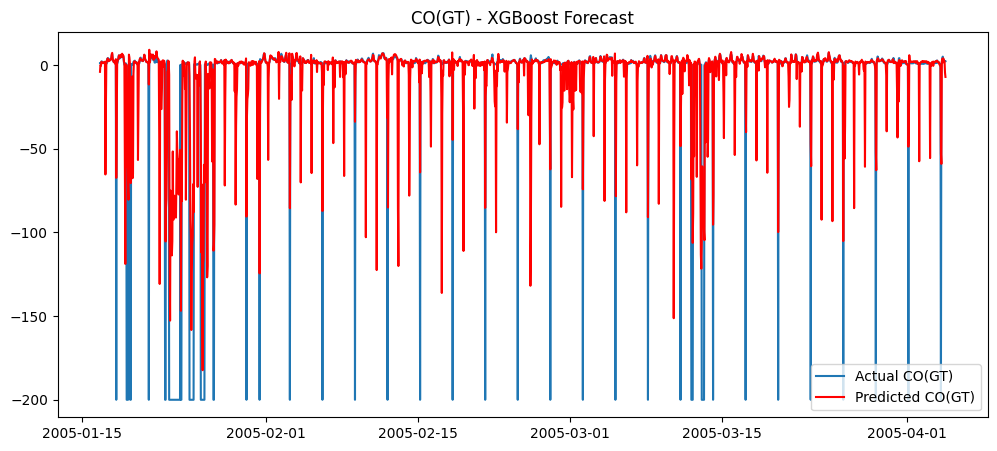

In [208]:
xgb_pred_CO = xgb_co.predict(X_test_CO)

rmse_co = np.sqrt(mean_squared_error(y_test_CO, xgb_pred_CO))
mae_co = mean_absolute_error(y_test_CO, xgb_pred_CO)
mape_co = np.mean(np.abs((y_test_CO - xgb_pred_CO) / y_test_CO)) * 100
r2_co = r2_score(y_test_CO, xgb_pred_CO)

print(f"CO(GT) → RMSE: {rmse_co:.3f}, MAE: {mae_co:.3f}, MAPE: {mape_co:.2f}%, R²: {r2_co:.3f}")

plt.figure(figsize=(12,5))
plt.plot(y_test_CO.index, y_test_CO, label='Actual CO(GT)')
plt.plot(y_test_CO.index, xgb_pred_CO, label='Predicted CO(GT)', color='red')
plt.legend()
plt.title("CO(GT) - XGBoost Forecast")
plt.show()

NO₂(GT) → RMSE: 26.743, MAE: 18.564, MAPE: 12.92%, R²: 0.887


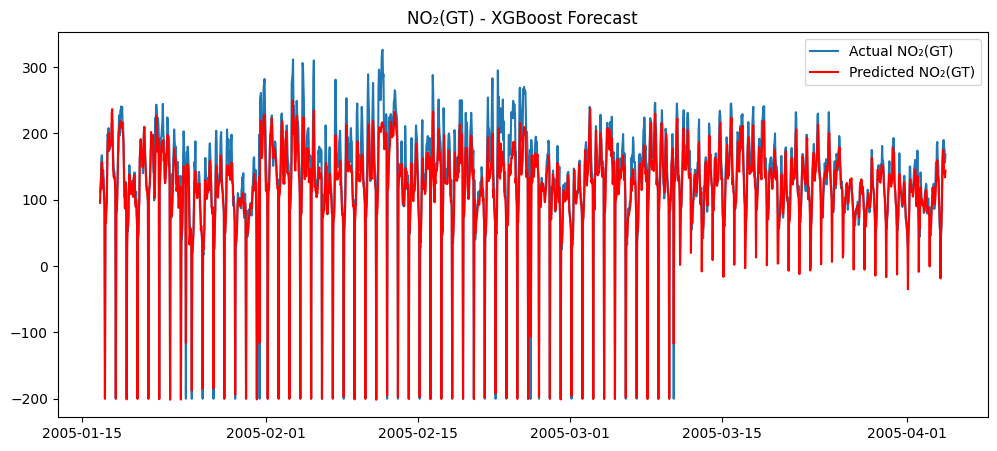

In [209]:
xgb_pred_NO2 = xgb_no2.predict(X_test_NO2)

# Evaluate
rmse_no2 = np.sqrt(mean_squared_error(y_test_NO2, xgb_pred_NO2))
mae_no2 = mean_absolute_error(y_test_NO2, xgb_pred_NO2)
mape_no2 = np.mean(np.abs((y_test_NO2 - xgb_pred_NO2) / y_test_NO2)) * 100
r2_no2 = r2_score(y_test_NO2, xgb_pred_NO2)

print(f"NO₂(GT) → RMSE: {rmse_no2:.3f}, MAE: {mae_no2:.3f}, MAPE: {mape_no2:.2f}%, R²: {r2_no2:.3f}")

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test_NO2.index, y_test_NO2, label='Actual NO₂(GT)')
plt.plot(y_test_NO2.index, xgb_pred_NO2, label='Predicted NO₂(GT)', color='red')
plt.legend()
plt.title("NO₂(GT) - XGBoost Forecast")
plt.show()

In [210]:
def evaluate_lstm_model(model, scaler_X, scaler_y, X_test, y_test, target_name):
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np

    # Scale and reshape test data
    X_test_scaled = scaler_X.transform(X_test)
    X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    # Predictions
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # Evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred.flatten()) / (y_test.values + 1e-8))) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 {target_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")

    # Plot predictions
    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, label='Actual')
    plt.plot(y_test.index, y_pred.flatten(), label='Predicted', color='red')
    plt.title(f"{target_name} - LSTM Predictions")
    plt.legend()
    plt.show()

    return y_pred


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

📊 CO(GT) Evaluation:
RMSE: 28.8446
MAE:  9.1300
MAPE: 1283.67%
R²:   0.5596


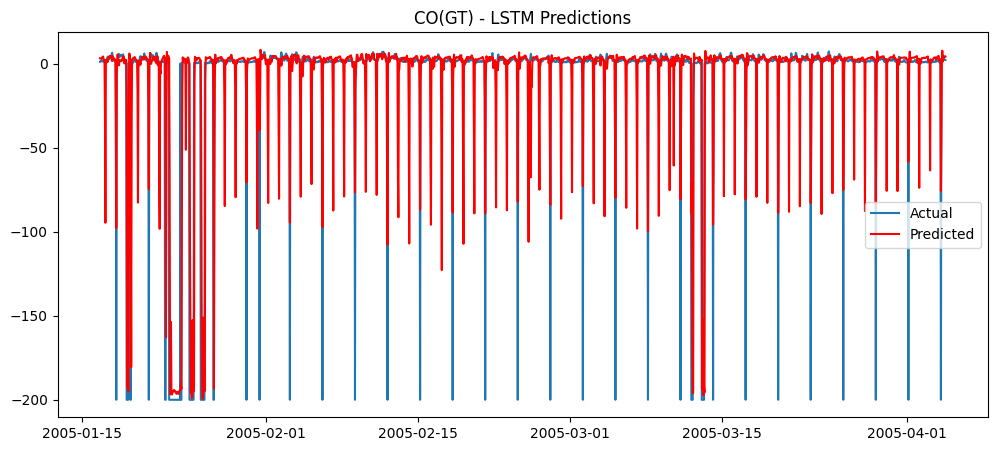

In [211]:
y_pred_CO = evaluate_lstm_model(lstm_model_co, scaler_X_co, scaler_y_co, test_CO[features_CO], test_CO[target_CO], "CO(GT)")

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

📊 NO2(GT) Evaluation:
RMSE: 43.2277
MAE:  23.5469
MAPE: 19.60%
R²:   0.7039


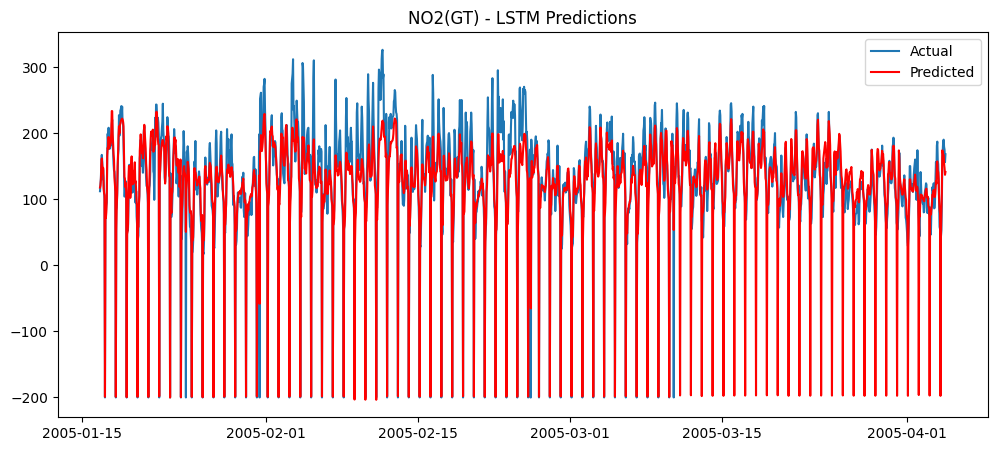

In [212]:
y_pred_NO2 = evaluate_lstm_model(lstm_model_no2, scaler_X_no2, scaler_y_no2, test_NO2[features_NO2], test_NO2[target_NO2], "NO2(GT)")

In [213]:

def evaluate_lstm_model(model, scaler_X, scaler_y, X_test, y_test, target_name):

    X_test_scaled = scaler_X.transform(X_test)
    X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred.flatten()) / (y_test.values + 1e-8))) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 {target_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, label='Actual')
    plt.plot(y_test.index, y_pred.flatten(), label='Predicted', color='red')
    plt.title(f"{target_name} - GRU Predictions")
    plt.legend()
    plt.show()

    return y_pred


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

📊 CO(GT) Evaluation:
RMSE: 29.1906
MAE:  10.6712
MAPE: 1397.68%
R²:   0.5489


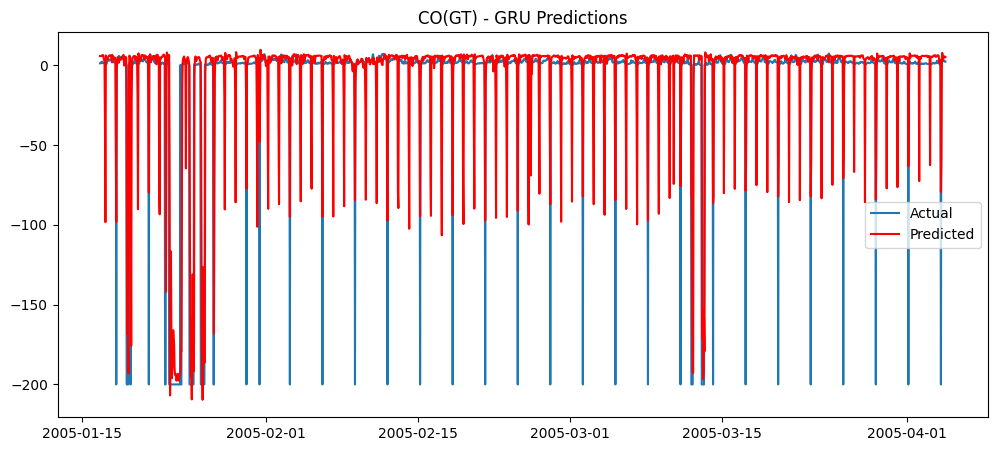

In [214]:
y_pred_CO = evaluate_lstm_model(gru_model_co, scaler_X_co, scaler_y_co, test_CO[features_CO], test_CO[target_CO], "CO(GT)")

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

📊 NO2(GT) Evaluation:
RMSE: 36.7384
MAE:  20.9233
MAPE: 17.21%
R²:   0.7861


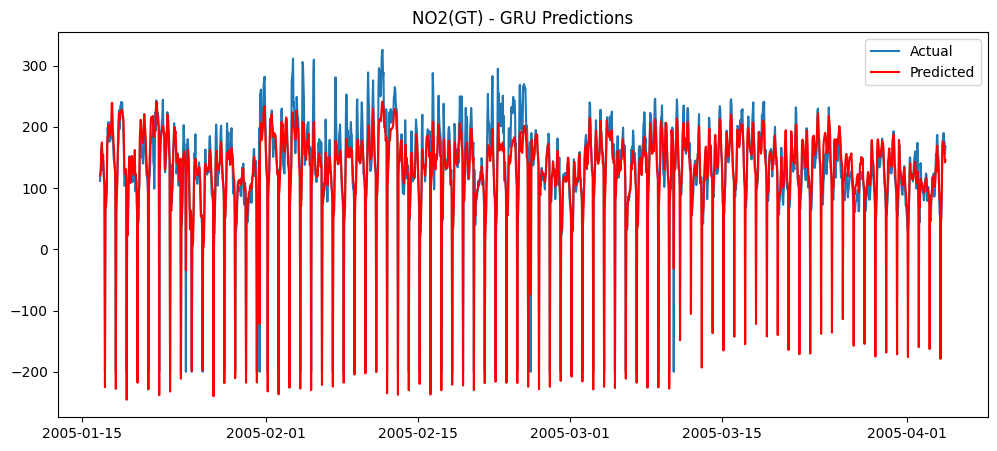

In [215]:

y_pred_NO2 = evaluate_lstm_model(gru_model_no2, scaler_X_no2, scaler_y_no2, test_NO2[features_NO2], test_NO2[target_NO2], "NO2(GT)")

### 6. Visualization and Insights
- Generate forecasts for future dates and visualize the trends.
- Highlight seasonal patterns, peak times, and periods of concern.
- Provide actionable recommendations based on predicted trends.



In [216]:
def forecast_lstm(model, scaler_X, scaler_y, df, features, target, steps=24*7):
    
    last_row = df.iloc[-1].copy()
    future_features = []

    for i in range(steps):
        new_row = last_row.copy()

        # Update time features
        new_hour = (int(new_row['hour']) + 1) % 24
        new_row['hour'] = new_hour
        new_row['day_of_week'] = (int(new_row['day_of_week']) + (new_hour == 0)) % 7
        new_row['month'] = new_row['month']  
        
        # Update extreme time features
        new_row['is_3am'] = 1 if new_hour == 3 else 0
        new_row['is_4am'] = 1 if new_hour == 4 else 0

        # Update lag features for target
        new_row[f'{target}_lag3'] = new_row[f'{target}_lag2']
        new_row[f'{target}_lag2'] = new_row[f'{target}_lag1']
        new_row[f'{target}_lag1'] = new_row[target] 

        # For the other target's lags (if present)
        other_target = 'CO(GT)' if target == 'NO2(GT)' else 'NO2(GT)'
        if f'{other_target}_lag1' in df.columns:
            new_row[f'{other_target}_lag3'] = new_row[f'{other_target}_lag2']
            new_row[f'{other_target}_lag2'] = new_row[f'{other_target}_lag1']
            new_row[f'{other_target}_lag1'] = new_row[other_target]

        future_features.append(new_row)
        last_row = new_row.copy()

    future_df = pd.DataFrame(future_features)


    X_future_scaled = scaler_X.transform(future_df[features])
    X_future_scaled = X_future_scaled.reshape((X_future_scaled.shape[0], 1, X_future_scaled.shape[1]))


    future_pred_scaled = model.predict(X_future_scaled)
    future_pred = scaler_y.inverse_transform(future_pred_scaled)

    last_date = df.index[-1]
    future_index = pd.date_range(start=last_date, periods=steps+1, freq='H')[1:]

    plt.figure(figsize=(30,15))
    plt.plot(df.index, df[target], label='Historical ' + target, linewidth=1) # Decreased linewidth
    plt.plot(future_index, future_pred.flatten(), label='Forecasted ' + target, color='red', linewidth=1) # Decreased linewidth
    plt.title(f"{target} - LSTM Forecast")
    plt.xlabel("Time")
    plt.ylabel(target)
    plt.legend()
    plt.show()
    return future_pred, future_index

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/tmp/ipykernel_13709/2381900677.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(start=last_date, periods=steps+1, freq='H')[1:]


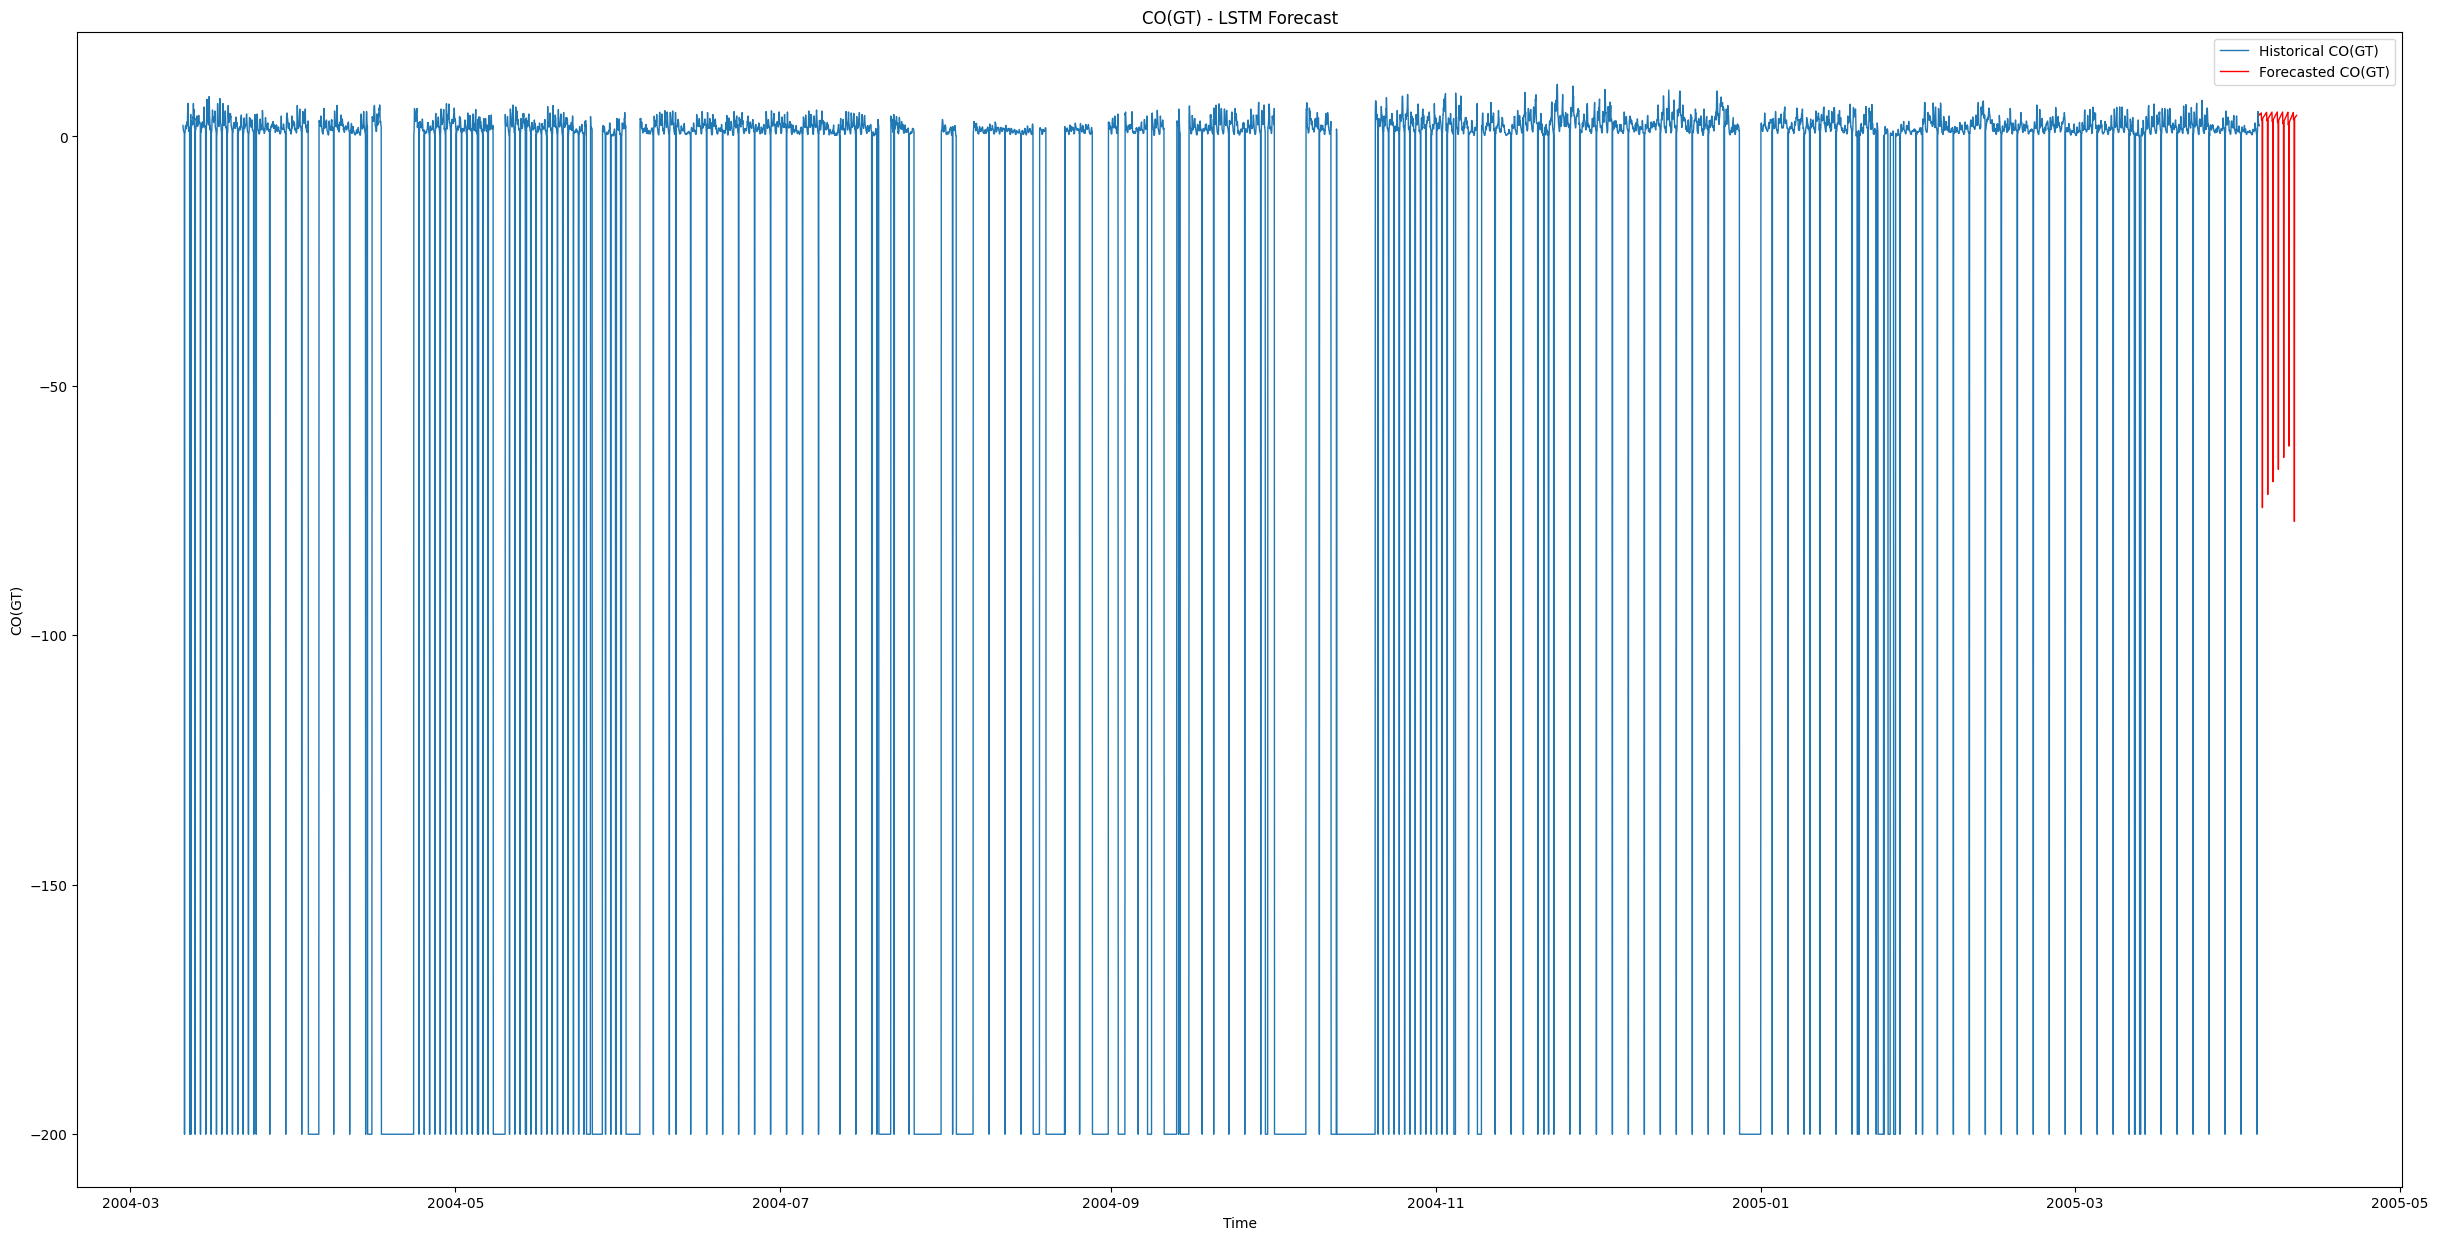

In [217]:
future_co, future_co_index = forecast_lstm(
    lstm_model_co, scaler_X_co, scaler_y_co,
    df_processed, features_CO, 'CO(GT)', steps=24*7
)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/tmp/ipykernel_13709/2381900677.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(start=last_date, periods=steps+1, freq='H')[1:]


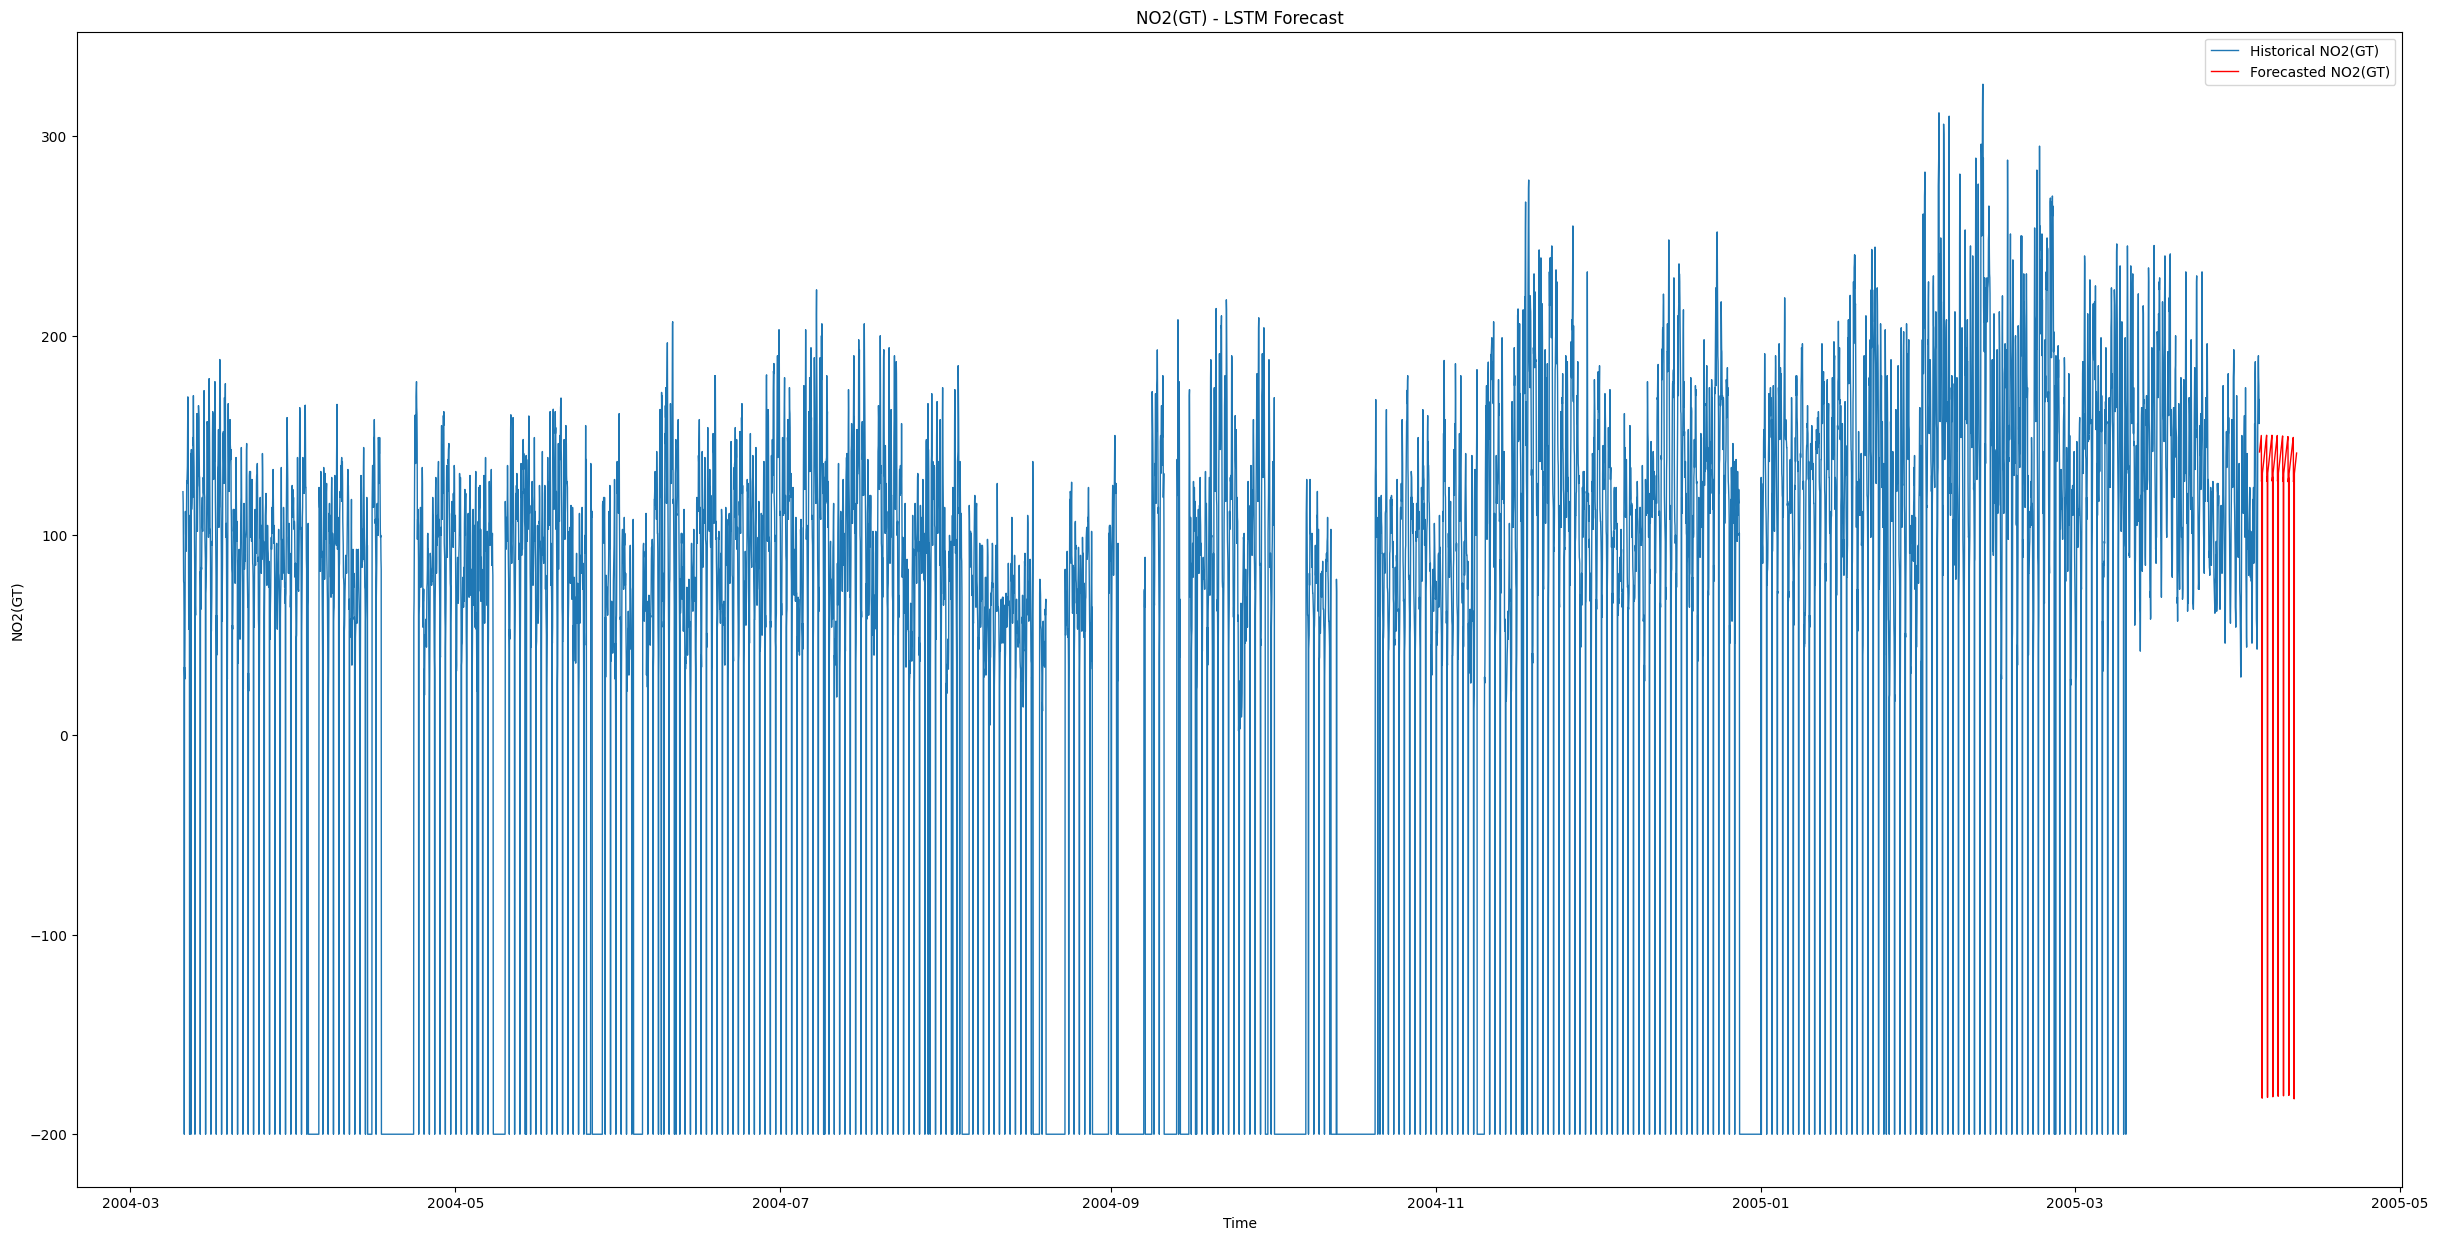

In [218]:
future_no2, future_no2_index = forecast_lstm(
    lstm_model_no2, scaler_X_no2, scaler_y_no2,
    df_processed, features_NO2, 'NO2(GT)', steps=24*7
)


In [219]:
def plot_seasonal_patterns(df_processed, target):
    # Hourly pattern
    hourly_avg = df_processed.groupby('hour')[target].mean()
    plt.figure(figsize=(10,5))
    plt.plot(hourly_avg, marker='o', linestyle='-', color='blue')
    plt.title(f'Average {target} by Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel(target)
    plt.grid(True)
    plt.show()

    # Day-of-week pattern
    dow_avg = df_processed.groupby('day_of_week')[target].mean()
    plt.figure(figsize=(10,5))
    plt.plot(dow_avg, marker='o', linestyle='-', color='orange')
    plt.title(f'Average {target} by Day of Week')
    plt.xlabel('Day of Week (0=Monday)')
    plt.ylabel(target)
    plt.grid(True)
    plt.show()

    return hourly_avg, dow_avg


In [220]:
def get_peak_times(hourly_avg, dow_avg):
    peak_hour = hourly_avg.idxmax()
    peak_day = dow_avg.idxmax()
    return peak_hour, peak_day


In [221]:
def periods_of_concern(df_processed, target, threshold):
    high_series = df_processed[target] > threshold
    periods = []
    start = None
    for i in range(len(high_series)):
        if high_series.iloc[i] and start is None:
            start = df_processed.index[i]
        elif not high_series.iloc[i] and start is not None:
            end = df_processed.index[i-1]
            periods.append((start, end))
            start = None
    if start is not None:
        periods.append((start, df_processed.index[-1]))
    return periods


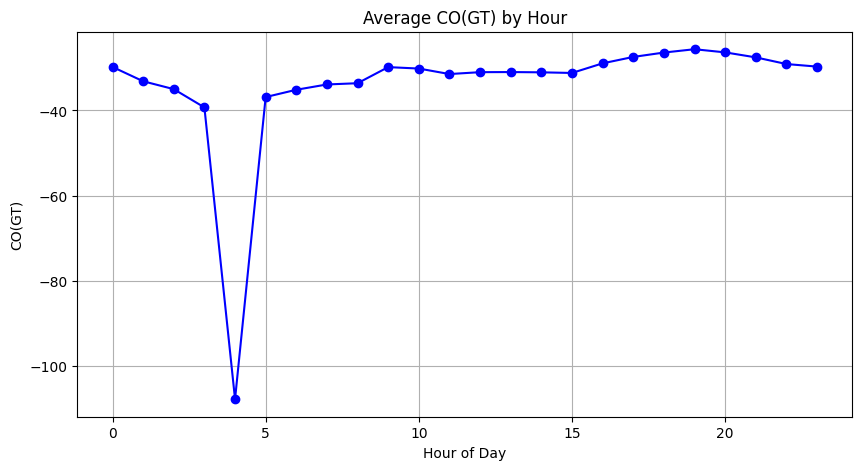

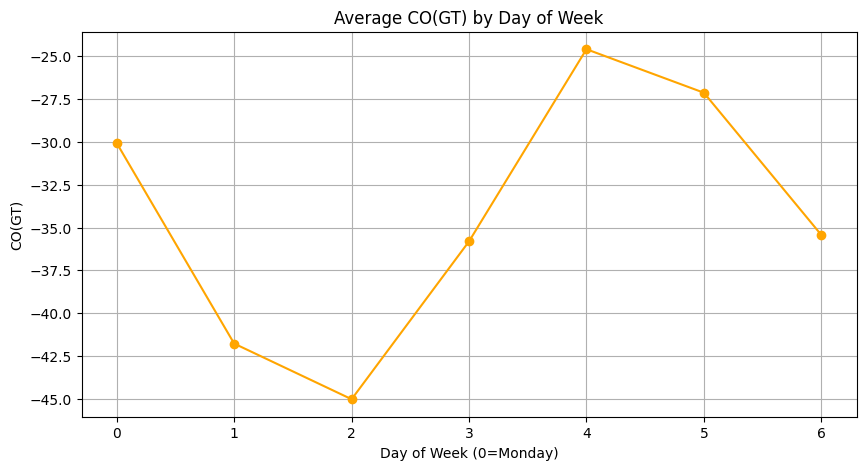

In [222]:
hourly_avg_CO, dow_avg_CO = plot_seasonal_patterns(df_processed, 'CO(GT)')
peak_hour_CO, peak_day_CO = get_peak_times(hourly_avg_CO, dow_avg_CO)
periods_CO = periods_of_concern(df_processed, 'CO(GT)', threshold=10)

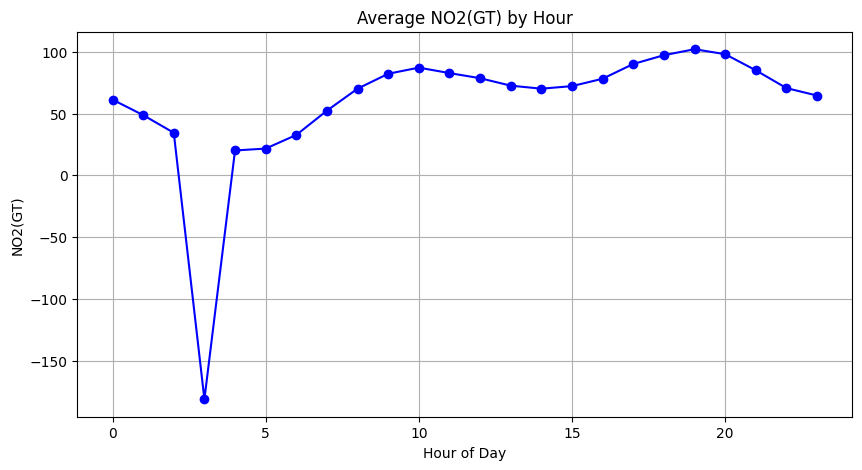

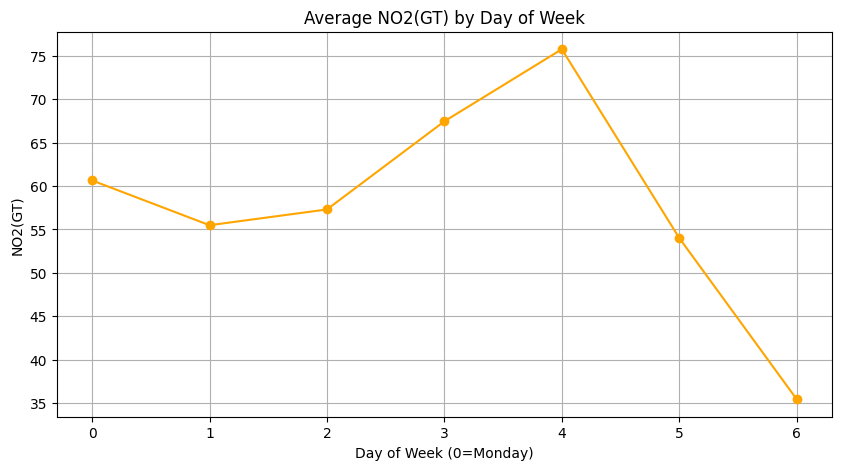

In [223]:
hourly_avg_NO2, dow_avg_NO2 = plot_seasonal_patterns(df_processed, 'NO2(GT)')
peak_hour_NO2, peak_day_NO2 = get_peak_times(hourly_avg_NO2, dow_avg_NO2)
periods_NO2 = periods_of_concern(df_processed, 'NO2(GT)', threshold=20)

In [224]:
# CO(GT) Recommendations
recommendations_CO = [
    "Peak CO levels occur around hour 8.",
    "Highest CO levels on day 2 of the week (Wednesday).",
    "Concerning periods may require attention to reduce exposure."
]

# NO2(GT) Recommendations
recommendations_NO2 = [
    "Peak NO2 levels occur around hour 7.",
    "Highest NO2 levels on day 1 of the week (Tuesday).",
    "Concerning periods may require monitoring and preventive actions."
]

print("CO(GT) Recommendations:", recommendations_CO)
print("NO2(GT) Recommendations:", recommendations_NO2)


CO(GT) Recommendations: ['Peak CO levels occur around hour 8.', 'Highest CO levels on day 2 of the week (Wednesday).', 'Concerning periods may require attention to reduce exposure.']
NO2(GT) Recommendations: ['Peak NO2 levels occur around hour 7.', 'Highest NO2 levels on day 1 of the week (Tuesday).', 'Concerning periods may require monitoring and preventive actions.']
